In [44]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    MinMaxScaler,
    LabelEncoder,
    OrdinalEncoder,
)
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [8]:
df = pd.read_csv("car_price_prediction_ (1).csv")
df.sample()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
1999,2000,Honda,2003,2.7,Diesel,Manual,235835,Used,54051.23,Accord


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [11]:
df["Brand"].unique()

array(['Tesla', 'BMW', 'Audi', 'Ford', 'Honda', 'Mercedes', 'Toyota'],
      dtype=object)

In [13]:
df["Condition"].unique() 

array(['New', 'Used', 'Like New'], dtype=object)

In [14]:
df["Transmission"].unique() 

array(['Manual', 'Automatic'], dtype=object)

In [15]:
df["Fuel Type"].unique() 

array(['Petrol', 'Electric', 'Diesel', 'Hybrid'], dtype=object)

In [12]:
df.drop(columns=['Car ID', 'Model'], inplace=True)

In [16]:
df = pd.concat([df, pd.get_dummies(df["Condition"])], axis=1)
df.drop(columns=["Condition"], inplace=True)

df = pd.concat([df, pd.get_dummies(df["Transmission"])], axis=1)
df.drop(columns=["Transmission"], inplace=True)

In [30]:
label_encoder = LabelEncoder()
df['Brand'] = label_encoder.fit_transform(df['Brand'])

In [31]:
df['Fuel Type'] = label_encoder.fit_transform(df['Fuel Type'])

In [32]:
df.head()

,Brand,Year,Engine Size,Fuel Type,Mileage,Price,Like New,New,Used,Automatic,Manual
0,5,2016,2.3,3,114832,26613.92,False,True,False,False,True
1,1,2018,4.4,1,143190,14679.61,False,False,True,False,True
2,0,2013,4.5,1,181601,44402.61,False,True,False,False,True
3,5,2011,4.1,0,68682,86374.33,False,True,False,True,False
4,2,2009,2.6,0,223009,73577.10,True,False,False,False,True


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Brand        2500 non-null   int64  
 1   Year         2500 non-null   int64  
 2   Engine Size  2500 non-null   float64
 3   Fuel Type    2500 non-null   int64  
 4   Mileage      2500 non-null   int64  
 5   Price        2500 non-null   float64
 6   Like New     2500 non-null   bool   
 7   New          2500 non-null   bool   
 8   Used         2500 non-null   bool   
 9   Automatic    2500 non-null   bool   
 10  Manual       2500 non-null   bool   
dtypes: bool(5), float64(2), int64(4)
memory usage: 129.5 KB


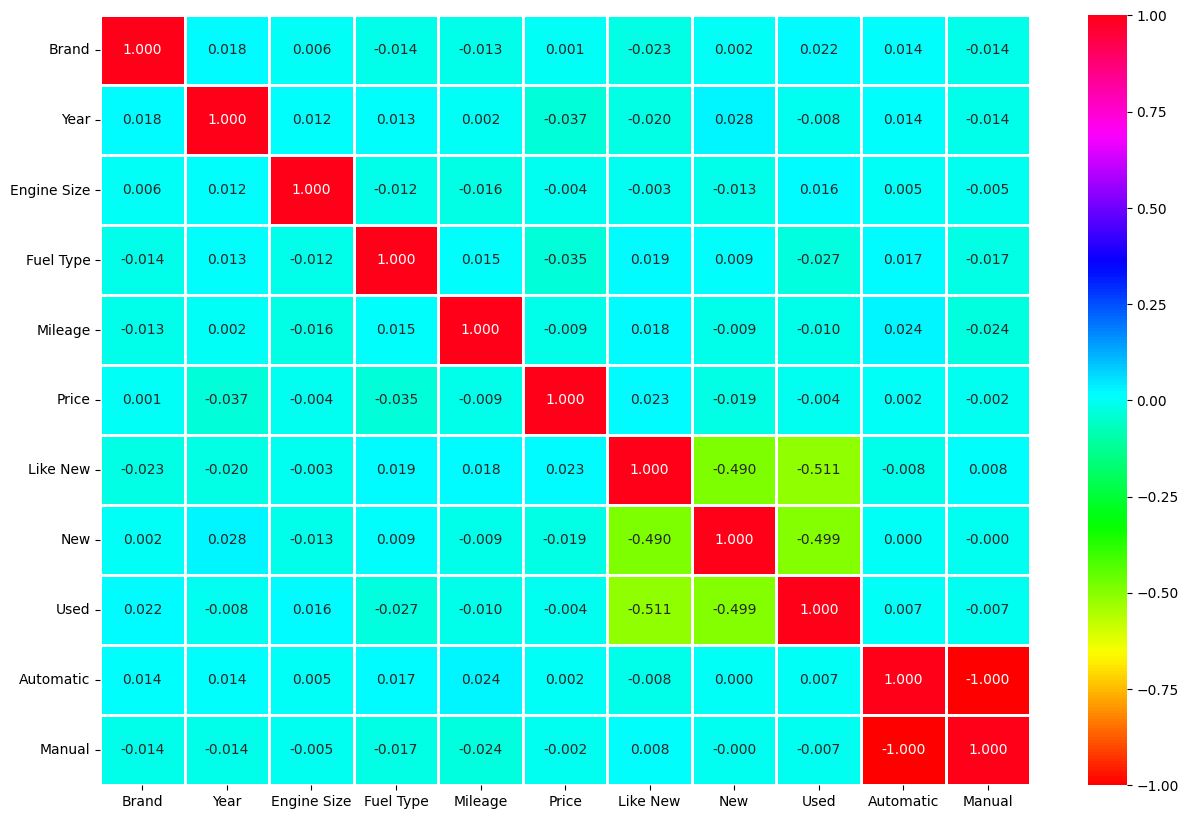

In [37]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='hsv', fmt='.3f', linewidths=2)
plt.show()

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(df.iloc[:, 1:-1], df.iloc[:, -1:], test_size = 0.2, random_state=0)

In [39]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [47]:
print(X_train_t.shape)


torch.Size([2000, 9])


In [48]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(np.asarray(Y_train).reshape(-1, 1), dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(np.asarray(Y_test).reshape(-1, 1), dtype=torch.float32)

# Create train/validation split (similar to validation_split=0.2)
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_train_t, Y_train_t, test_size=0.2, random_state=0
)

train_ds = TensorDataset(X_tr, Y_tr)
val_ds = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train_ds, batch_size=12, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=12, shuffle=False)

# Define regression network: 
class AdmissionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 16),  
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()     
        )

    def forward(self, x):
        return self.net(x)

model = AdmissionNet()

criterion = nn.MSELoss()                
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [49]:
num_epochs = 20
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---- Train ----
    model.train()
    running_train = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * xb.size(0)

    epoch_train_loss = running_train / len(train_loader.dataset)

    # ---- Validate ----
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val += loss.item() * xb.size(0)

    epoch_val_loss = running_val / len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"train_loss={epoch_train_loss:.4f}, "
          f"val_loss={epoch_val_loss:.4f}")

Epoch 1/20, train_loss=0.2443, val_loss=0.2058
Epoch 2/20, train_loss=0.1231, val_loss=0.0979
Epoch 3/20, train_loss=0.0876, val_loss=0.0835
Epoch 4/20, train_loss=0.0742, val_loss=0.0717
Epoch 5/20, train_loss=0.0641, val_loss=0.0619
Epoch 6/20, train_loss=0.0548, val_loss=0.0536
Epoch 7/20, train_loss=0.0480, val_loss=0.0466
Epoch 8/20, train_loss=0.0414, val_loss=0.0407
Epoch 9/20, train_loss=0.0365, val_loss=0.0357
Epoch 10/20, train_loss=0.0317, val_loss=0.0314
Epoch 11/20, train_loss=0.0284, val_loss=0.0278
Epoch 12/20, train_loss=0.0251, val_loss=0.0247
Epoch 13/20, train_loss=0.0221, val_loss=0.0219
Epoch 14/20, train_loss=0.0199, val_loss=0.0196
Epoch 15/20, train_loss=0.0183, val_loss=0.0176
Epoch 16/20, train_loss=0.0167, val_loss=0.0159
Epoch 17/20, train_loss=0.0147, val_loss=0.0143
Epoch 18/20, train_loss=0.0134, val_loss=0.0129
Epoch 19/20, train_loss=0.0118, val_loss=0.0117
Epoch 20/20, train_loss=0.0106, val_loss=0.0106


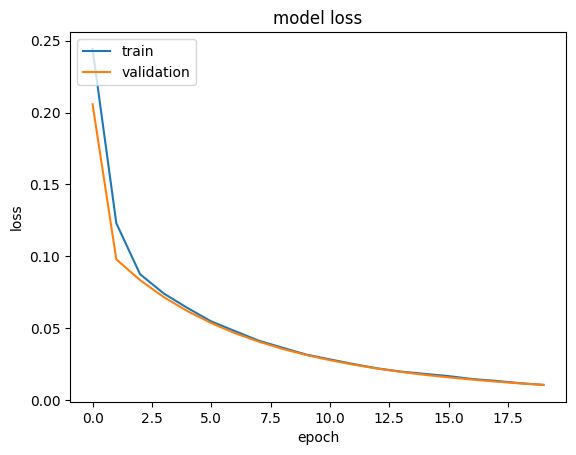

In [50]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [51]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy().flatten()

y_pred[:10]

array([0.14493121, 0.14493121, 1.        , 1.        , 0.14493121,
       1.        , 0.14493121, 0.14493121, 1.        , 1.        ],
      dtype=float32)

In [52]:
from sklearn.metrics import r2_score
print("r_square score: ", r2_score(Y_test,y_pred))

r_square score:  0.9609571434972884


In [65]:
class RegNet_Simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 16),
            nn.ReLU(),
             nn.Dropout(0.1),
            nn.Linear(16, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.net(x)

model2 = RegNet_Simple()

criterion = nn.MSELoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)


In [66]:
num_epochs = 17
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---- Train ----
    model2.train()
    running_train = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model2(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * xb.size(0)

    epoch_train_loss = running_train / len(train_loader.dataset)

    # ---- Validate ----
    model2.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model2(xb)
            loss = criterion(outputs, yb)
            running_val += loss.item() * xb.size(0)

    epoch_val_loss = running_val / len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"train_loss={epoch_train_loss:.4f}, "
          f"val_loss={epoch_val_loss:.4f}")

Epoch 1/17, train_loss=0.2233, val_loss=0.1787
Epoch 2/17, train_loss=0.1413, val_loss=0.0905
Epoch 3/17, train_loss=0.0622, val_loss=0.0333
Epoch 4/17, train_loss=0.0262, val_loss=0.0134
Epoch 5/17, train_loss=0.0131, val_loss=0.0064
Epoch 6/17, train_loss=0.0074, val_loss=0.0036
Epoch 7/17, train_loss=0.0048, val_loss=0.0021
Epoch 8/17, train_loss=0.0033, val_loss=0.0014
Epoch 9/17, train_loss=0.0025, val_loss=0.0010
Epoch 10/17, train_loss=0.0018, val_loss=0.0007
Epoch 11/17, train_loss=0.0015, val_loss=0.0005
Epoch 12/17, train_loss=0.0011, val_loss=0.0004
Epoch 13/17, train_loss=0.0009, val_loss=0.0003
Epoch 14/17, train_loss=0.0009, val_loss=0.0002
Epoch 15/17, train_loss=0.0008, val_loss=0.0002
Epoch 16/17, train_loss=0.0006, val_loss=0.0001
Epoch 17/17, train_loss=0.0005, val_loss=0.0001


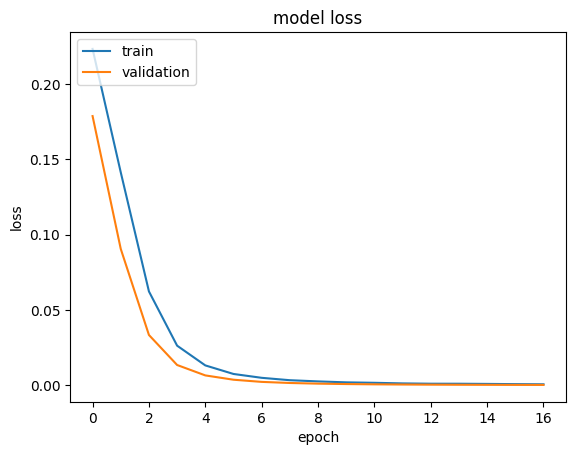

In [67]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [68]:
model.eval()
with torch.no_grad():
    y_pred = model2(X_test_t).numpy().flatten()

y_pred[:10]

array([0.01059327, 0.0088382 , 0.98798287, 0.9898891 , 0.00900006,
       0.99050516, 0.00920502, 0.00899755, 0.9883839 , 0.9876815 ],
      dtype=float32)

In [69]:
from sklearn.metrics import r2_score
print("r_square score: ", r2_score(Y_test,y_pred))

r_square score:  0.9995028445735492
